# Battery Health Analysis
### Data Cleaning, Exploratory Data Analysis & Predictive Modeling

# Week 2 – Data Analysis

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("battery_cycle_level_dataset_CLEAN_FINAL.csv")

In [5]:
df

,battery_id,cycle,voltage,temperature,capacity,soh,rul
0,B0005,1,3.532781,32.536891,1.861976,1.000000,167
1,B0005,2,3.542968,32.643595,1.851862,0.994568,166
2,B0005,3,3.553056,32.522526,1.840808,0.988631,165
3,B0005,4,3.545849,32.492083,1.850058,0.993599,164
4,B0005,5,3.544456,32.368612,1.849432,0.993263,163
...,...,...,...,...,...,...,...
1410,B0053,54,3.080080,12.530864,1.292799,0.988320,1
1411,B0053,55,3.063813,12.900294,1.312809,1.003617,0
1412,B0054,1,3.205983,12.489230,0.853855,1.000000,0
1413,B0055,1,3.153346,12.207199,0.854758,1.000000,0


In [5]:
df.head()

,battery_id,cycle,voltage,temperature,capacity,soh,rul
0,B0005,1,3.532781,32.536891,1.861976,1.000000,167
1,B0005,2,3.542968,32.643595,1.851862,0.994568,166
2,B0005,3,3.553056,32.522526,1.840808,0.988631,165
3,B0005,4,3.545849,32.492083,1.850058,0.993599,164
4,B0005,5,3.544456,32.368612,1.849432,0.993263,163


In [6]:
print("Shape : ", df.shape)

Shape :  (1415, 7)


In [7]:
print("INFO : ")
df.info()

INFO : 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1415 entries, 0 to 1414
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   battery_id   1415 non-null   object 
 1   cycle        1415 non-null   int64  
 2   voltage      1415 non-null   float64
 3   temperature  1415 non-null   float64
 4   capacity     1415 non-null   float64
 5   soh          1415 non-null   float64
 6   rul          1415 non-null   int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 77.5+ KB


In [8]:
df.isnull().sum()

battery_id     0
cycle          0
voltage        0
temperature    0
capacity       0
soh            0
rul            0
dtype: int64

In [9]:
# NO NULL VALUE IN ANY COLUMN

In [10]:
df.duplicated().sum() # NO DUPLICATE VALUES IN DATASET

np.int64(0)

In [11]:
df.dtypes

battery_id      object
cycle            int64
voltage        float64
temperature    float64
capacity       float64
soh            float64
rul              int64
dtype: object

In [12]:
df.describe()

,cycle,voltage,temperature,capacity,soh,rul
count,1415.000000,1415.000000,1415.000000,1415.000000,1415.000000,1415.000000
mean,55.389399,3.420612,26.589773,1.501191,0.849014,54.175972
std,42.728497,0.166460,13.196045,0.316995,0.119219,43.709204
min,1.000000,2.530010,7.684550,0.520105,0.604449,0.000000
25%,21.000000,3.387078,9.555186,1.321640,0.750777,16.500000
50%,43.000000,3.452596,31.139259,1.504115,0.850350,43.000000
75%,87.000000,3.507450,32.753400,1.709022,0.961174,86.000000
max,168.000000,3.753027,54.997372,2.498996,1.048527,167.000000


In [13]:
df["battery_id"].nunique() # 34 Batteries data

34

In [14]:
# Range Validation
print("SOH Range")
print(df["soh"].min(), df["soh"].max())

print("\nCapacity Range")
print(df["capacity"].min(), df["capacity"].max())

print("\nTemperature Range")
print(df["temperature"].min(), df["temperature"].max())

SOH Range
0.604448676087178 1.0485271606255615

Capacity Range
0.520104892932856 2.4989960513448937

Temperature Range
7.684549736519659 54.99737199703748


<Axes: xlabel='capacity'>

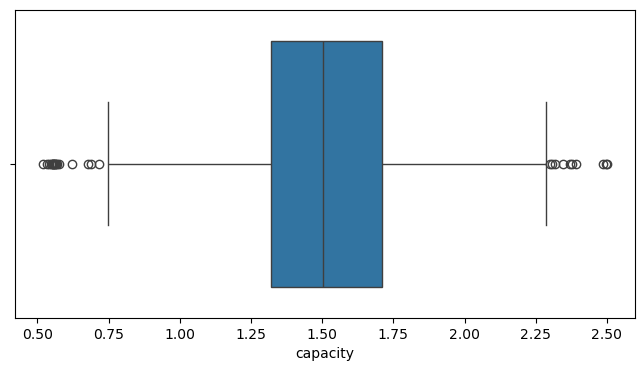

In [15]:
# CAPACITY OUTLIER DETECTION
plt.figure(figsize = (8, 4))
sns.boxplot(
    x = df["capacity"]
)

<Axes: xlabel='temperature'>

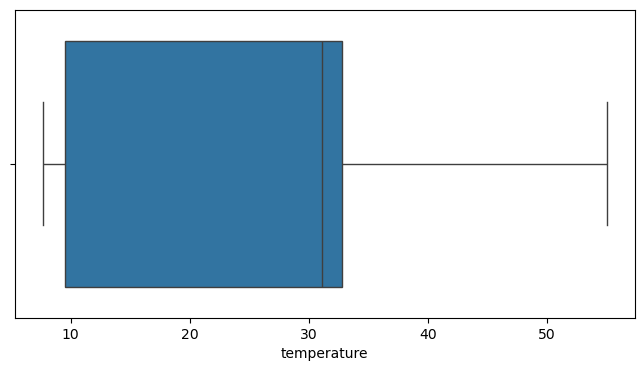

In [16]:
# TEMPERATURE OUTLIER DETECTION
plt.figure(figsize = (8, 4))
sns.boxplot(
    x = df["temperature"]
)

<Axes: >

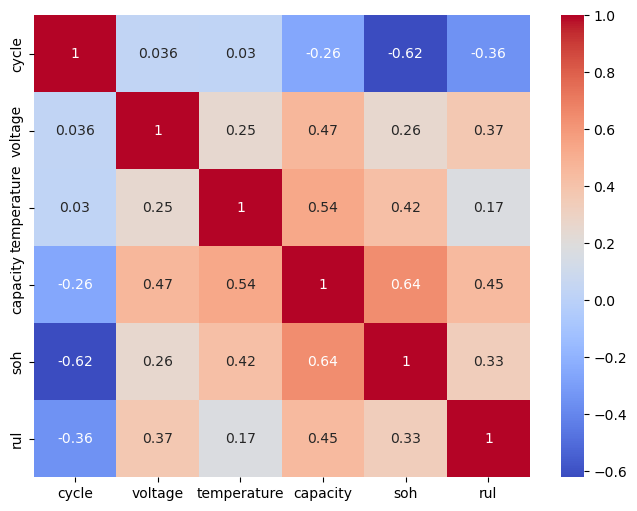

In [17]:
# Checking SOH depends on what using heatmap
plt.figure(figsize = (8, 6))
sns.heatmap(
    df.corr(numeric_only = True),
    annot = True,
    cmap = "coolwarm"
)

# Week 3 – Exploratory Data Analysis & Visualization

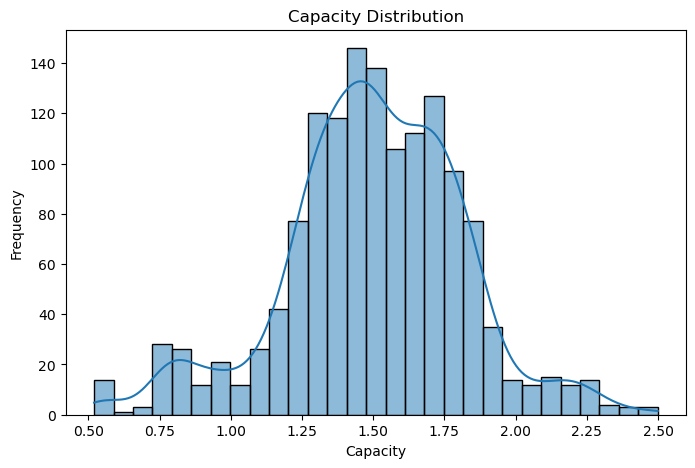

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df["capacity"], kde=True)
plt.title("Capacity Distribution")
plt.xlabel("Capacity")
plt.ylabel("Frequency")
plt.show()

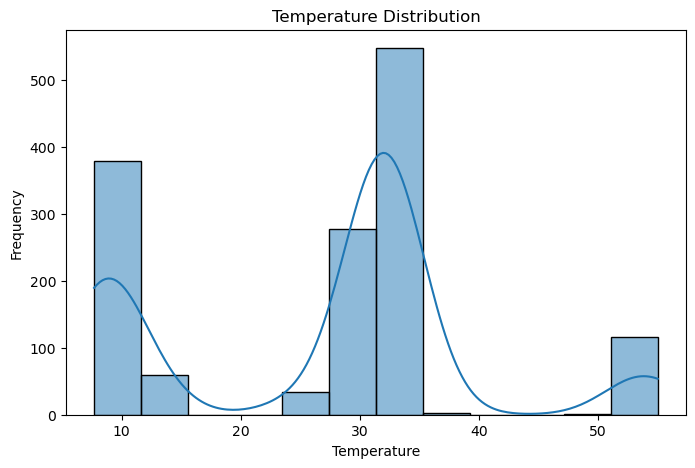

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df["temperature"], kde=True)
plt.title("Temperature Distribution")
plt.xlabel("Temperature")
plt.ylabel("Frequency")
plt.show()

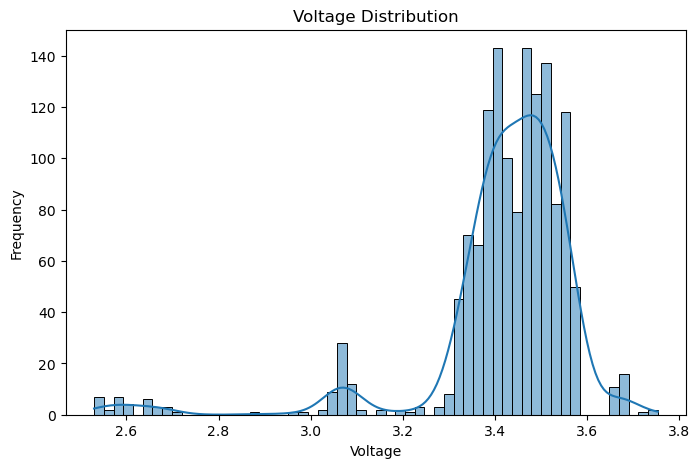

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df["voltage"], kde=True)
plt.title("Voltage Distribution")
plt.xlabel("Voltage")
plt.ylabel("Frequency")
plt.show()

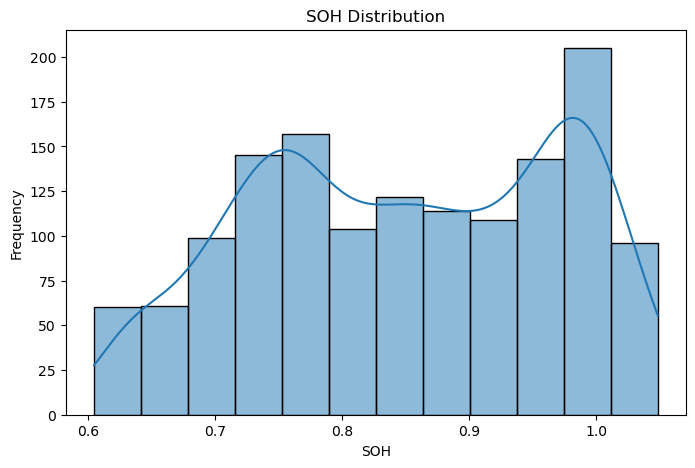

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df["soh"], kde=True)
plt.title("SOH Distribution")
plt.xlabel("SOH")
plt.ylabel("Frequency")
plt.show()

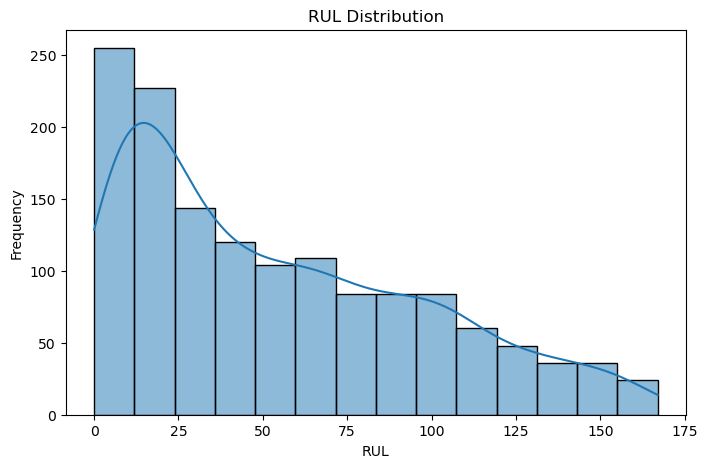

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(df["rul"], kde=True)
plt.title("RUL Distribution")
plt.xlabel("RUL")
plt.ylabel("Frequency")
plt.show()

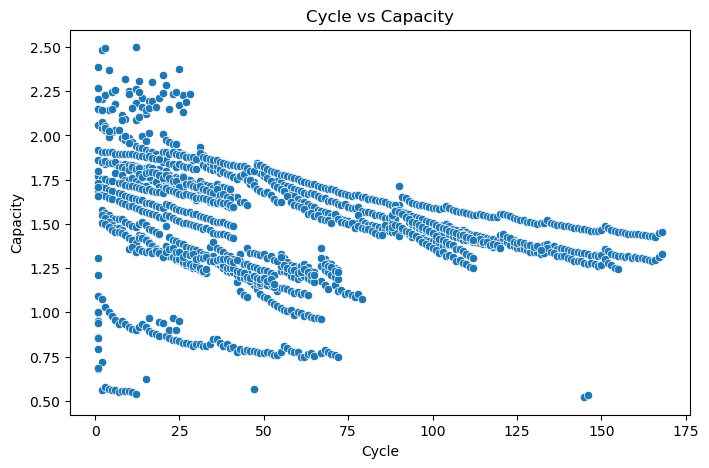

In [23]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="cycle", y="capacity")
plt.title("Cycle vs Capacity")
plt.xlabel("Cycle")
plt.ylabel("Capacity")
plt.show()

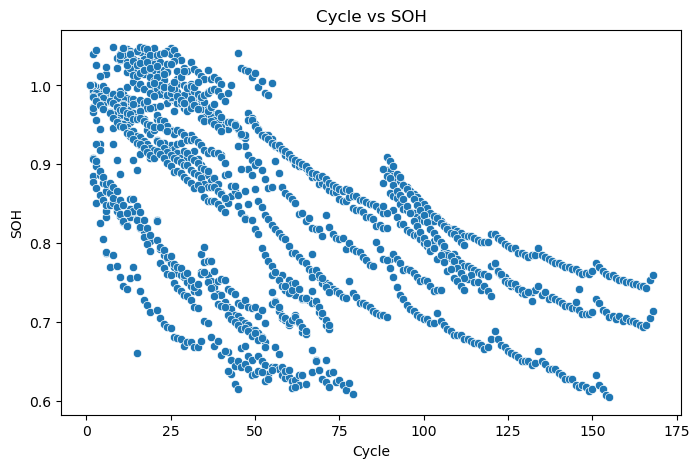

In [24]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="cycle", y="soh")
plt.title("Cycle vs SOH")
plt.xlabel("Cycle")
plt.ylabel("SOH")
plt.show()

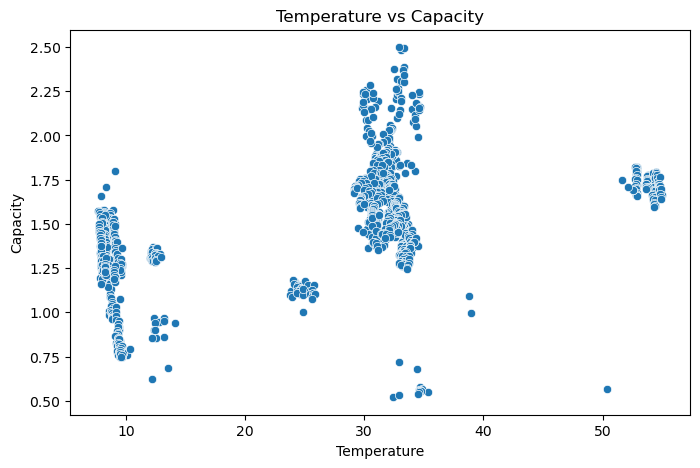

In [25]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="temperature", y="capacity")
plt.title("Temperature vs Capacity")
plt.xlabel("Temperature")
plt.ylabel("Capacity")
plt.show()

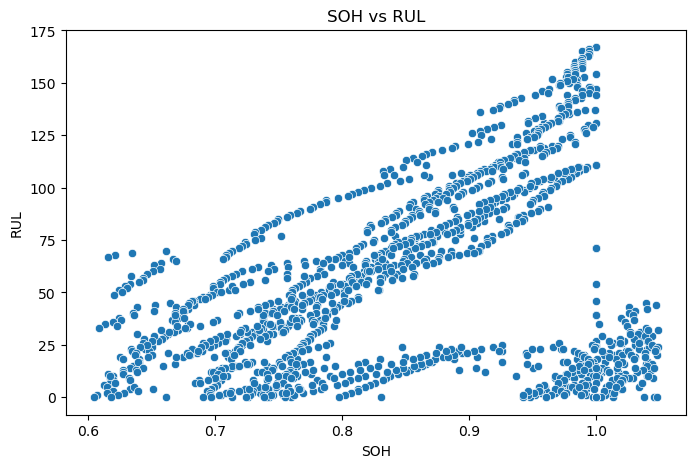

In [26]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="soh", y="rul")
plt.title("SOH vs RUL")
plt.xlabel("SOH")
plt.ylabel("RUL")
plt.show()

In [27]:
df[["cycle", "voltage", "temperature", "capacity", "soh", "rul"]].describe()

,cycle,voltage,temperature,capacity,soh,rul
count,1415.000000,1415.000000,1415.000000,1415.000000,1415.000000,1415.000000
mean,55.389399,3.420612,26.589773,1.501191,0.849014,54.175972
std,42.728497,0.166460,13.196045,0.316995,0.119219,43.709204
min,1.000000,2.530010,7.684550,0.520105,0.604449,0.000000
25%,21.000000,3.387078,9.555186,1.321640,0.750777,16.500000
50%,43.000000,3.452596,31.139259,1.504115,0.850350,43.000000
75%,87.000000,3.507450,32.753400,1.709022,0.961174,86.000000
max,168.000000,3.753027,54.997372,2.498996,1.048527,167.000000


# Week 4 – Predictive Modeling & Feature Engineering

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

In [6]:
X = df[["cycle", "voltage", "temperature", "capacity"]]
y = df["soh"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   cycle   voltage  temperature  capacity
0      1  3.532781    32.536891  1.861976
1      2  3.542968    32.643595  1.851862
2      3  3.553056    32.522526  1.840808
3      4  3.545849    32.492083  1.850058
4      5  3.544456    32.368612  1.849432

Target:
0    1.000000
1    0.994568
2    0.988631
3    0.993599
4    0.993263
Name: soh, dtype: float64


In [8]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1415, 4)
y shape: (1415,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1132
Testing samples: 283


In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [11]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

print("Linear Regression completed.")

Linear Regression completed.


In [12]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree completed.")

Decision Tree completed.


In [13]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest completed.")

Random Forest completed.


In [14]:
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return {
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R² Score": r2
    }

In [15]:
results = []

results.append(evaluate_model(
    "Linear Regression",
    y_test,
    lr_pred
))

results.append(evaluate_model(
    "Decision Tree",
    y_test,
    dt_pred
))

results.append(evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
))

In [16]:
results_df = pd.DataFrame(results)

print(results_df)

               Model       MAE       MSE      RMSE  R² Score
0  Linear Regression  0.053367  0.005262  0.072539  0.622114
1      Decision Tree  0.010274  0.000644  0.025381  0.953735
2      Random Forest  0.008263  0.000360  0.018968  0.974161


In [17]:
results_df

,Model,MAE,MSE,RMSE,R² Score
0,Linear Regression,0.053367,0.005262,0.072539,0.622114
1,Decision Tree,0.010274,0.000644,0.025381,0.953735
2,Random Forest,0.008263,0.000360,0.018968,0.974161


In [18]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
3,capacity,0.606647
0,cycle,0.175475
2,temperature,0.129407
1,voltage,0.088471


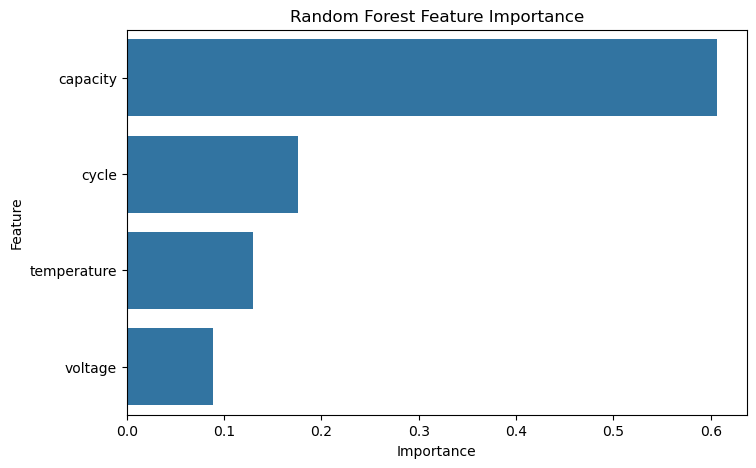

In [21]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

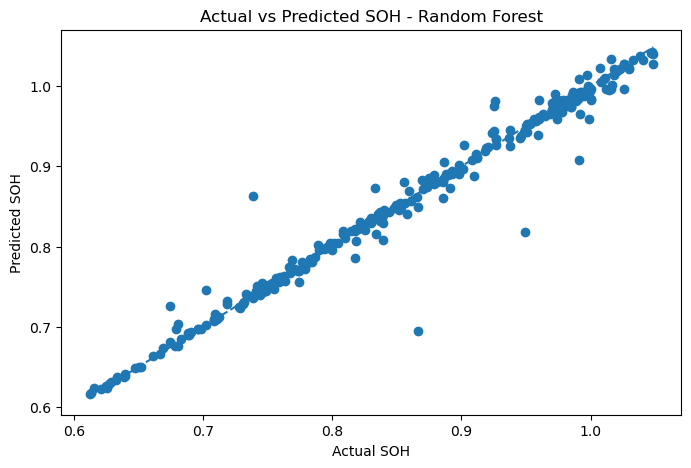

In [22]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, rf_pred)

plt.xlabel("Actual SOH")
plt.ylabel("Predicted SOH")
plt.title("Actual vs Predicted SOH - Random Forest")

# Perfect prediction reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()